# 🏓 Testeo y Evaluación de YOLO OBB (Oriented Bounding Boxes)

Este notebook permite cargar el mejor modelo entrenado (`best.pt`) y evaluar sus métricas en el conjunto de validación y testeo, además de visualizar predicciones de cajas orientadas (rotadas).

### 1. Instalación de Dependencias y Configuración
Instalamos la librería de Ultralytics (YOLO) y otras dependencias necesarias si es que no están instaladas, y definimos el directorio del dataset.

In [5]:
# Instalar Ultralytics
%pip install ultralytics roboflow matplotlib opencv-python numpy pyyaml

import os
import glob
import random
from ultralytics import YOLO
from IPython.display import Image, display


EXTRACT_DIR = "./dataset_obb"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 5. Validar el Modelo
Una vez completado el entrenamiento, podemos validar las métricas obtenidas con el mejor modelo guardado.

In [6]:
import glob
from ultralytics import YOLO

# Buscar dinámicamente el archivo best.pt para evitar errores de rutas de Ultralytics
best_weights = glob.glob('**/weights/best.pt', recursive=True)

if best_weights:
    best_path = best_weights[0]
    print(f"🎯 Cargando mejor modelo desde: {best_path}")
    best_model = YOLO(best_path)
    # Validar
    metrics = best_model.val()
    print("✅ Métricas de validación calculadas con éxito.\n")
    
    # Mostrar métricas generales textualmente
    print("--- Métricas Generales (Cajas Orientadas - OBB) ---")
    print(f"Precisión media (mAP50):      {metrics.box.map50:.4f}")
    print(f"Precisión media (mAP50-95):   {metrics.box.map:.4f}")
    print(f"Precisión (Precision):        {metrics.box.mp:.4f}")
    print(f"Exhaustividad (Recall):       {metrics.box.mr:.4f}\n")
    
    # Mostrar métricas por clase
    print("--- Métricas por Clase ---")
    names = best_model.names
    for i, class_name in names.items():
        ap50 = metrics.box.ap50[i]
        ap = metrics.box.ap[i]
        p = metrics.box.p[i]
        r = metrics.box.r[i]
        print(f"Clase {i} ({class_name}):")
        print(f"  mAP50:      {ap50:.4f}")
        print(f"  mAP50-95:   {ap:.4f}")
        print(f"  Precision:  {p:.4f}")
        print(f"  Recall:     {r:.4f}\n")
else:
    print("❌ ERROR: No se encontró el archivo best.pt. Asegúrate de haber completado el entrenamiento.")

🎯 Cargando mejor modelo desde: runs\obb\runs\tenis_mesa_obb_run\weights\best.pt
Ultralytics 8.4.54  Python-3.12.10 torch-2.12.0+cpu CPU (AMD Ryzen 5 2600 Six-Core Processor)
YOLO26n-obb summary (fused): 132 layers, 2,446,992 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 302.646.8 MB/s, size: 50.9 KB)
val: Scanning C:\Users\Ignac\Universidad\Materias\Redes Neuronales\TPI\dataset_obb\valid\labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.0s/it 2.0s
                   all         15         72      0.795      0.599      0.655       0.43
                TT Net         13         20       0.73        0.6      0.684      0.467
             TT Racket         15         29      0.757      0.431      0.484      0.316
              TT Table         15         23      0.898      0.765      0.798      0.505
Speed: 

### 6. Visualizar Métricas y Gráficos del Entrenamiento
YOLO genera automáticamente gráficos con el progreso de las pérdidas (losses) y las precisiones (mAP50, mAP50-95) a lo largo de las épocas, así como la matriz de confusión.

📊 Cargando resultados de la carpeta: runs\obb\runs\tenis_mesa_obb_run\
--- Curvas de Pérdidas y Métricas (mAP50 / mAP50-95) ---


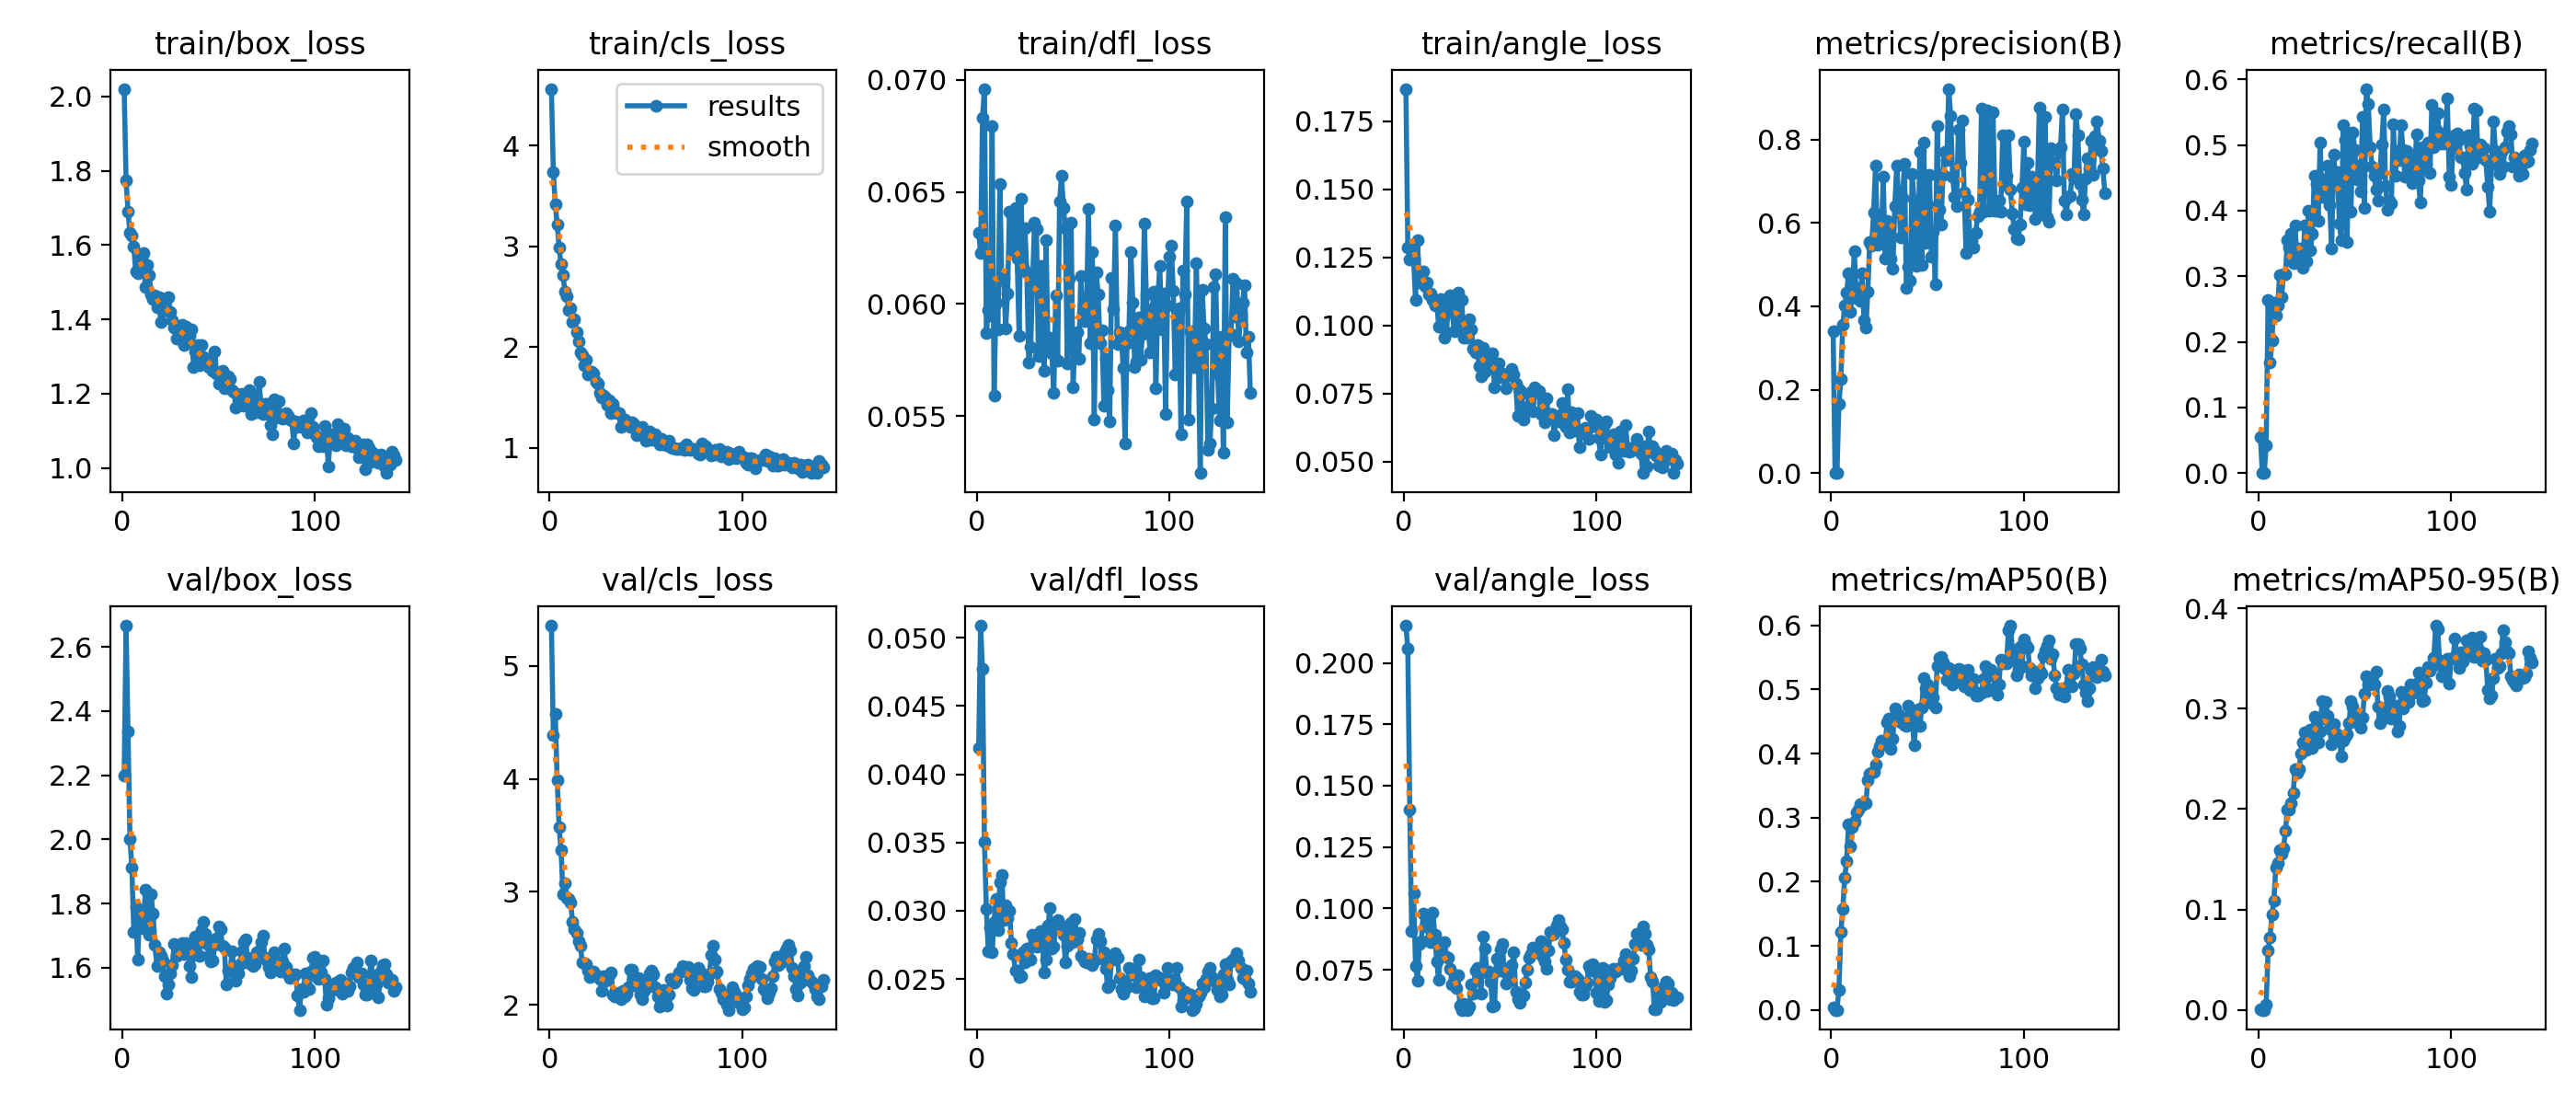


--- Matriz de Confusión ---


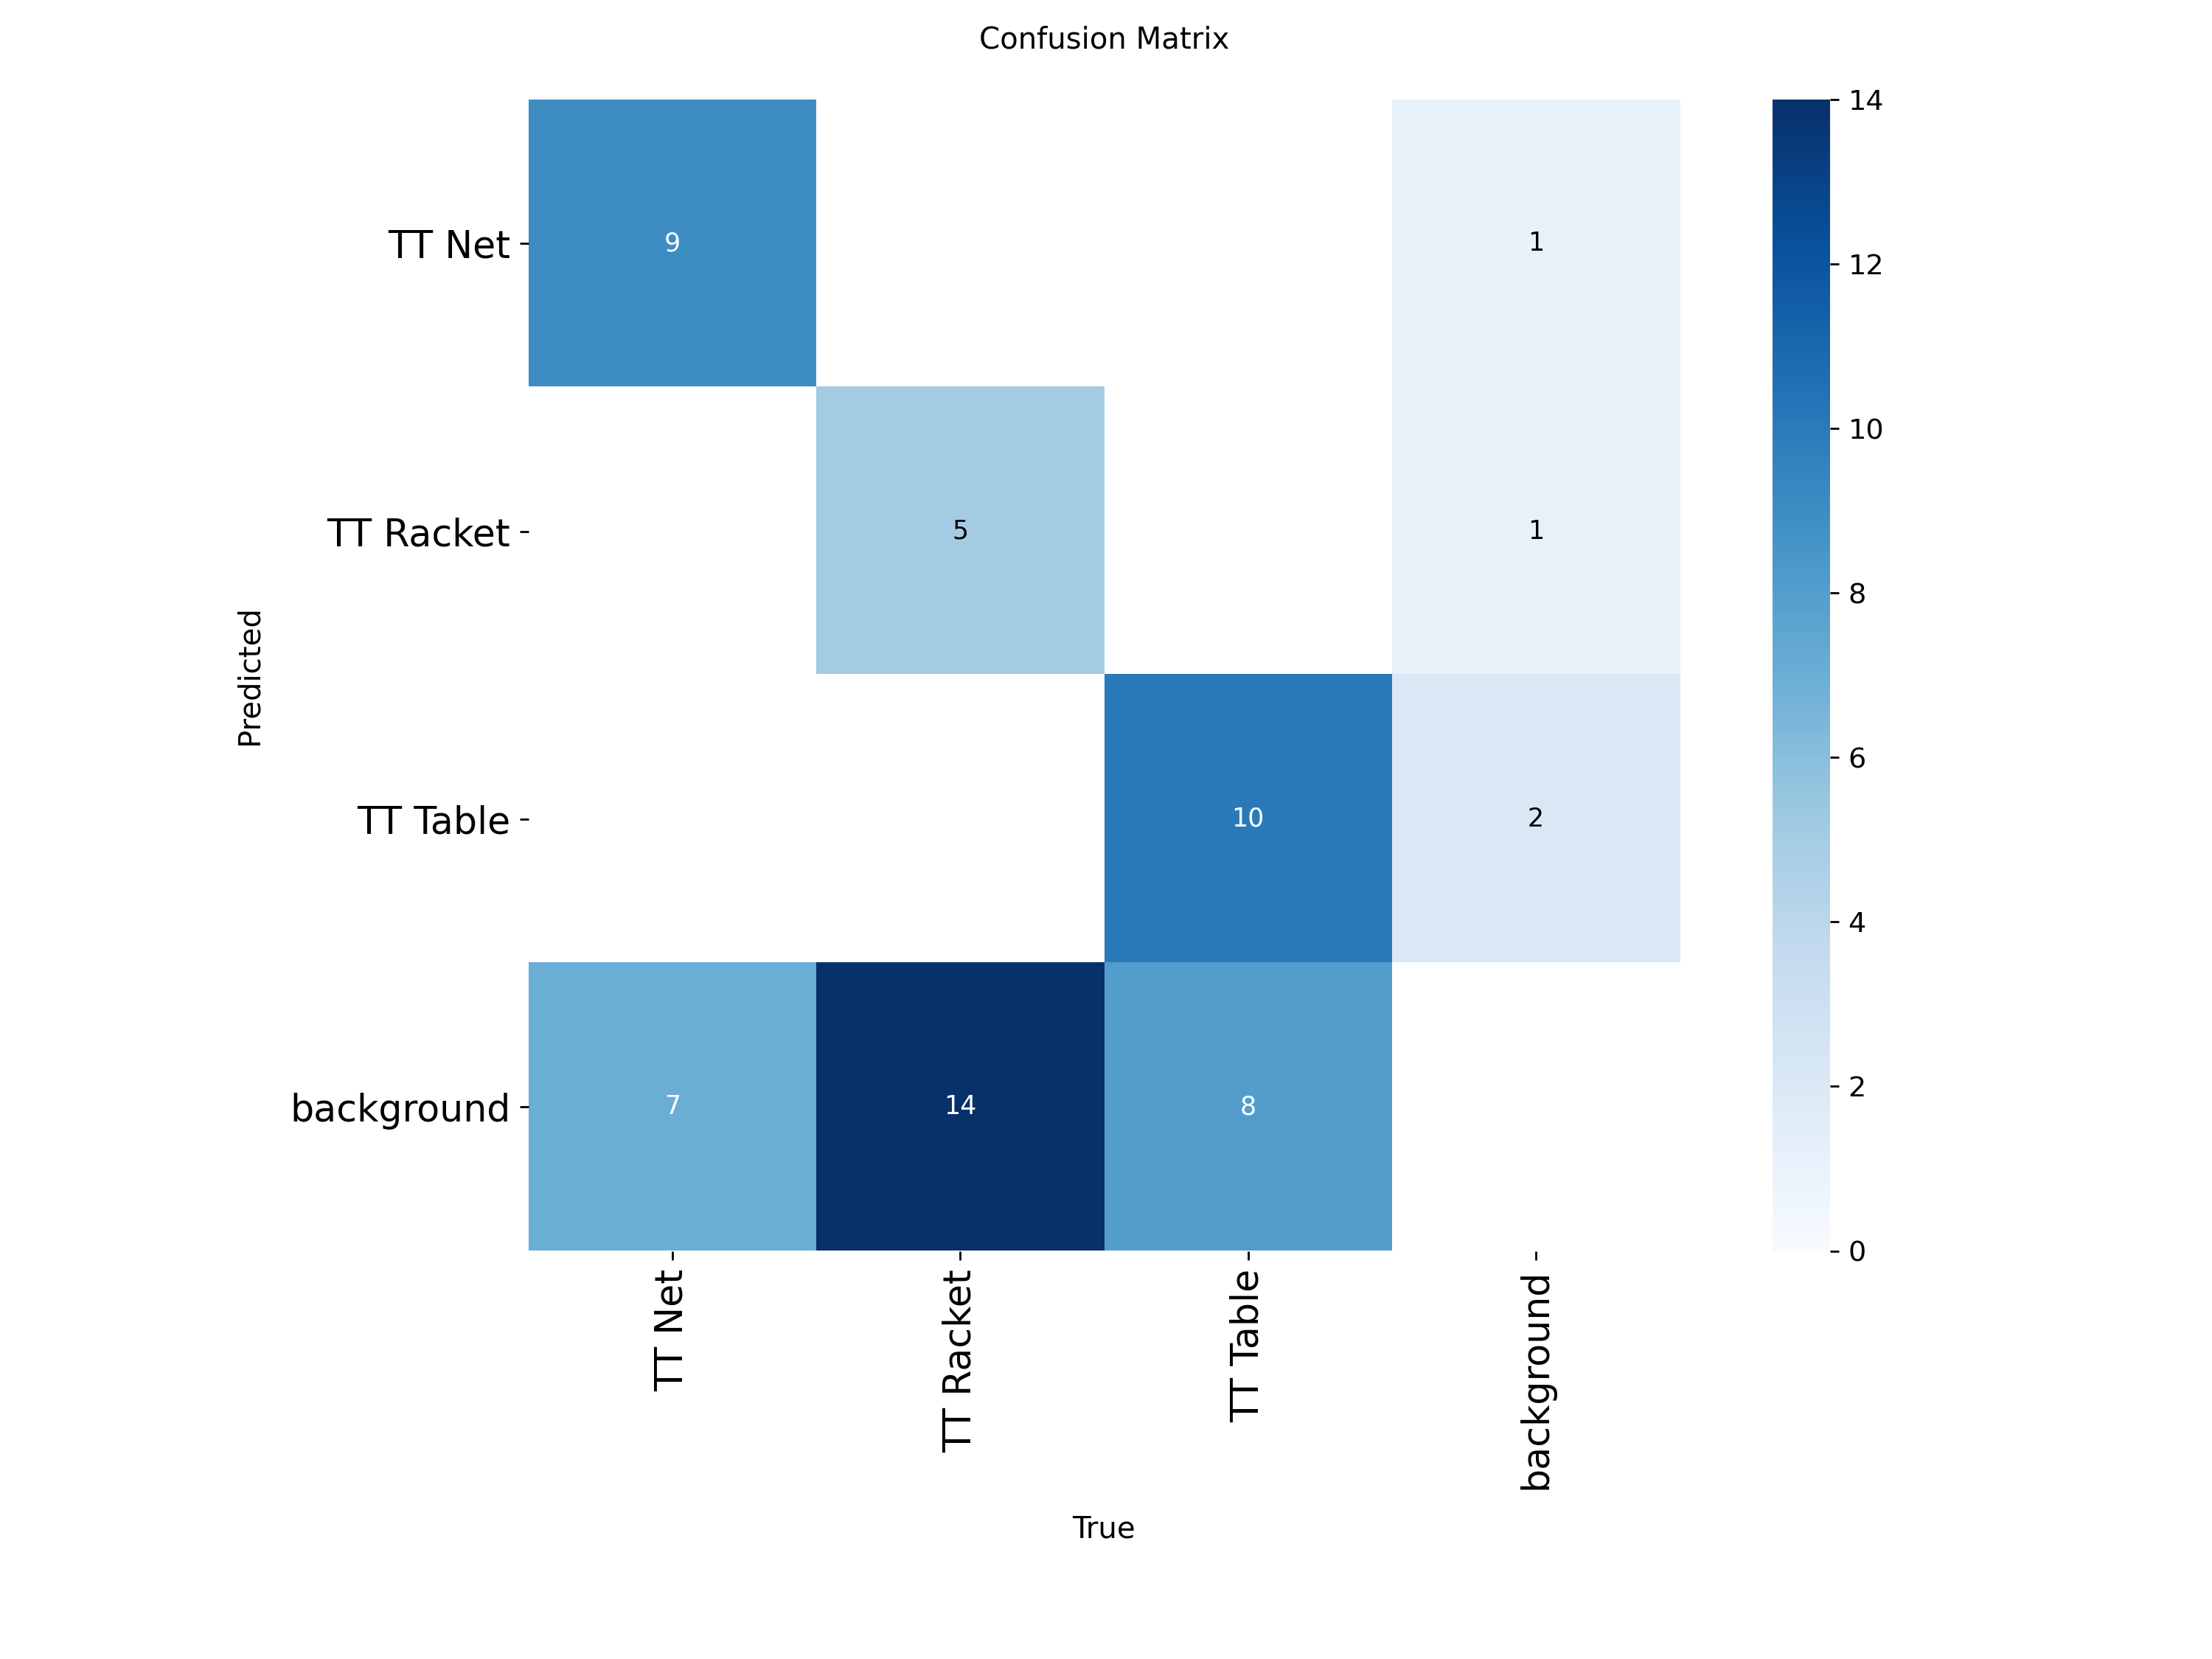

In [7]:
from IPython.display import Image, display
import os
import glob

# Encontrar dinámicamente la carpeta del entrenamiento
results_dirs = glob.glob('**/tenis_mesa_obb_run/', recursive=True)

if results_dirs:
    results_dir = results_dirs[0]
    print(f"📊 Cargando resultados de la carpeta: {results_dir}")

    # 1. Mostrar gráfico de pérdidas y métricas del entrenamiento
    results_png = os.path.join(results_dir, 'results.png')
    if os.path.exists(results_png):
        print("--- Curvas de Pérdidas y Métricas (mAP50 / mAP50-95) ---")
        display(Image(filename=results_png, width=800))
    else:
        print("No se encontró results.png en el directorio de resultados.")

    # 2. Mostrar la Matriz de Confusión
    confusion_matrix_png = os.path.join(results_dir, 'confusion_matrix.png')
    if os.path.exists(confusion_matrix_png):
        print("\n--- Matriz de Confusión ---")
        display(Image(filename=confusion_matrix_png, width=600))
    else:
        print("No se encontró la matriz de confusión.")
else:
    print("❌ ERROR: No se encontró la carpeta del entrenamiento tenis_mesa_obb_run.")

### 7. Realizar Predicciones en Imágenes de Testeo (Inferencia OBB)
Hacemos predicciones en algunas imágenes del conjunto de testeo para visualizar cómo el modelo detecta y orienta las cajas de tenis de mesa (red, raqueta, mesa).

🎯 Cargando mejor modelo para inferencia desde: runs\obb\runs\tenis_mesa_obb_run\weights\best.pt
🖼️ Realizando predicciones sobre 3 imágenes del split de testeo...

image 1/1 c:\Users\Ignac\Universidad\Materias\Redes Neuronales\TPI\dataset_obb\test\images\Screenshot-2026-06-09-195901_png.rf.ddb5c4be566ad1274c47f91b66e82d05.jpg: 640x640 1 TT Table, 121.6ms
Speed: 3.7ms preprocess, 121.6ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\Ignac\Universidad\Materias\Redes Neuronales\TPI\runs\obb\predict-2
Mostrando predicción para: Screenshot-2026-06-09-195901_png.rf.ddb5c4be566ad1274c47f91b66e82d05.jpg


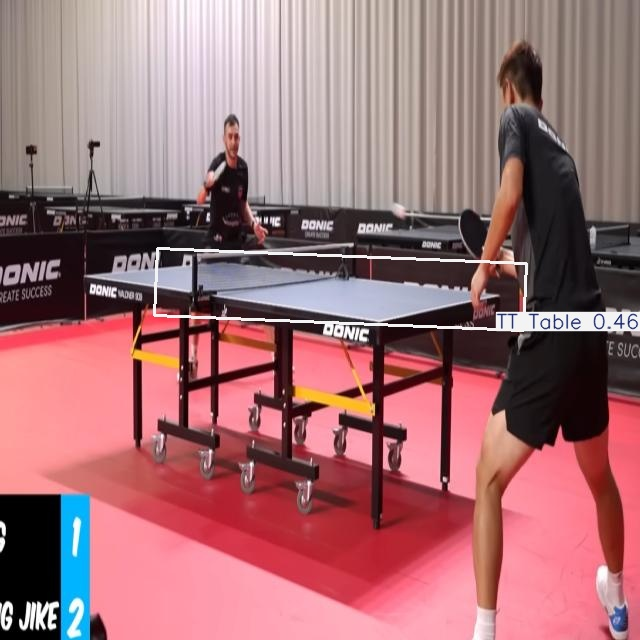


image 1/1 c:\Users\Ignac\Universidad\Materias\Redes Neuronales\TPI\dataset_obb\test\images\suggested-GH6SLpbcV8JUvMUhE9RZ_jpg.rf.8ebe4a1659ec27019f77eb62d72bf7d6.jpg: 640x640 1 TT Net, 1 TT Table, 132.9ms
Speed: 3.8ms preprocess, 132.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\Ignac\Universidad\Materias\Redes Neuronales\TPI\runs\obb\predict-2
Mostrando predicción para: suggested-GH6SLpbcV8JUvMUhE9RZ_jpg.rf.8ebe4a1659ec27019f77eb62d72bf7d6.jpg


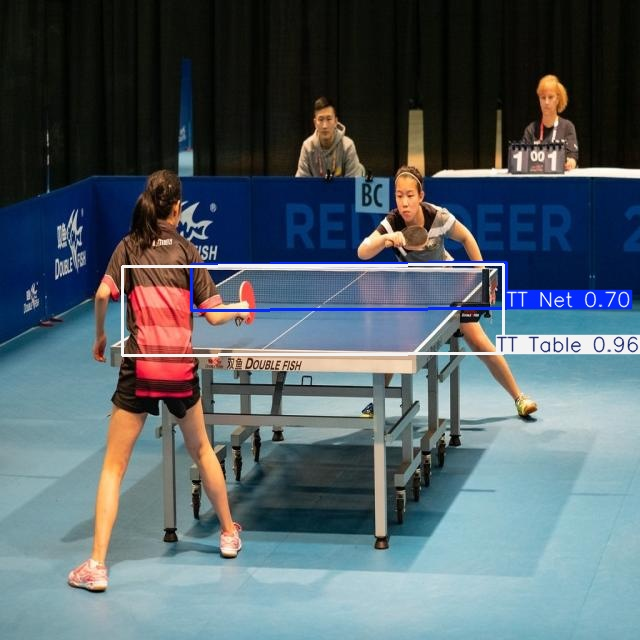


image 1/1 c:\Users\Ignac\Universidad\Materias\Redes Neuronales\TPI\dataset_obb\test\images\Screenshot-2026-06-09-195350_png.rf.47359330ccea80f09f93aa90e7b8a9a6.jpg: 640x640 3 TT Rackets, 1 TT Table, 123.6ms
Speed: 4.1ms preprocess, 123.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\Ignac\Universidad\Materias\Redes Neuronales\TPI\runs\obb\predict-2
Mostrando predicción para: Screenshot-2026-06-09-195350_png.rf.47359330ccea80f09f93aa90e7b8a9a6.jpg


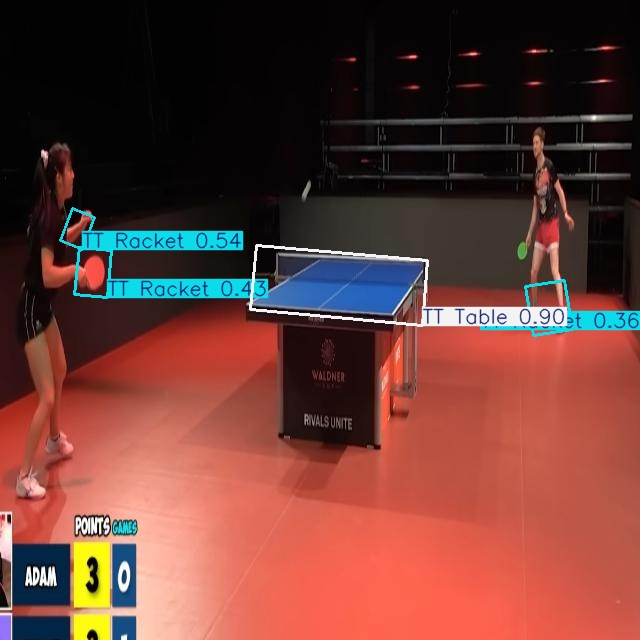

In [8]:
# Buscar imágenes en el conjunto de test
test_images = glob.glob(os.path.join(EXTRACT_DIR, 'test/images/*.jpg'))
if not test_images:
    test_images = glob.glob(os.path.join(EXTRACT_DIR, 'test/images/*.png'))

# Buscar el mejor modelo de pesos
best_weights = glob.glob('**/weights/best.pt', recursive=True)

if best_weights and test_images:
    best_path = best_weights[0]
    print(f"🎯 Cargando mejor modelo para inferencia desde: {best_path}")
    best_model = YOLO(best_path)
    
    # Seleccionar 3 imágenes aleatorias de prueba
    sample_images = random.sample(test_images, min(3, len(test_images)))
    print(f"🖼️ Realizando predicciones sobre {len(sample_images)} imágenes del split de testeo...")
    
    for img_path in sample_images:
        # Realizar predicción guardando el resultado de forma orientada (OBB)
        results = best_model.predict(source=img_path, save=True, imgsz=640)
        
        # Mostrar el resultado guardado
        for r in results:
            if r.save_dir:
                pred_img_path = os.path.join(r.save_dir, os.path.basename(img_path))
                if os.path.exists(pred_img_path):
                    print(f"Mostrando predicción para: {os.path.basename(img_path)}")
                    display(Image(filename=pred_img_path, width=600))
                else:
                    print(f"No se pudo encontrar la imagen de predicción en {pred_img_path}")
else:
    if not best_weights:
        print("❌ ERROR: No se encontró el archivo best.pt. Asegúrate de haber entrenado el modelo.")
    if not test_images:
        print("❌ ERROR: No se encontraron imágenes en './dataset_obb/test/images/' para testear.")